In [84]:
import torch
import numpy as np
import matplotlib.pyplot as plt

In [85]:
import torch.nn as nn

In [86]:
X = torch.linspace(1,50, 50).reshape(-1,1)
X

tensor([[ 1.],
        [ 2.],
        [ 3.],
        [ 4.],
        [ 5.],
        [ 6.],
        [ 7.],
        [ 8.],
        [ 9.],
        [10.],
        [11.],
        [12.],
        [13.],
        [14.],
        [15.],
        [16.],
        [17.],
        [18.],
        [19.],
        [20.],
        [21.],
        [22.],
        [23.],
        [24.],
        [25.],
        [26.],
        [27.],
        [28.],
        [29.],
        [30.],
        [31.],
        [32.],
        [33.],
        [34.],
        [35.],
        [36.],
        [37.],
        [38.],
        [39.],
        [40.],
        [41.],
        [42.],
        [43.],
        [44.],
        [45.],
        [46.],
        [47.],
        [48.],
        [49.],
        [50.]])

In [87]:
torch.manual_seed(71)
e = torch.randint(-8,9,(50,1), dtype=torch.float)
e

tensor([[ 2.],
        [ 7.],
        [ 2.],
        [ 6.],
        [ 2.],
        [-4.],
        [ 2.],
        [-5.],
        [ 4.],
        [ 1.],
        [ 2.],
        [ 3.],
        [ 1.],
        [-8.],
        [ 5.],
        [ 5.],
        [-6.],
        [ 0.],
        [-7.],
        [-8.],
        [-3.],
        [-1.],
        [ 2.],
        [-6.],
        [-3.],
        [ 3.],
        [ 2.],
        [ 3.],
        [ 4.],
        [ 5.],
        [ 1.],
        [ 7.],
        [ 6.],
        [-1.],
        [-6.],
        [-5.],
        [-3.],
        [ 7.],
        [ 0.],
        [ 8.],
        [-1.],
        [-2.],
        [ 2.],
        [-8.],
        [-1.],
        [ 6.],
        [-8.],
        [-3.],
        [-7.],
        [-2.]])

In [88]:
y = 2*X + 1 + e
y.shape

torch.Size([50, 1])

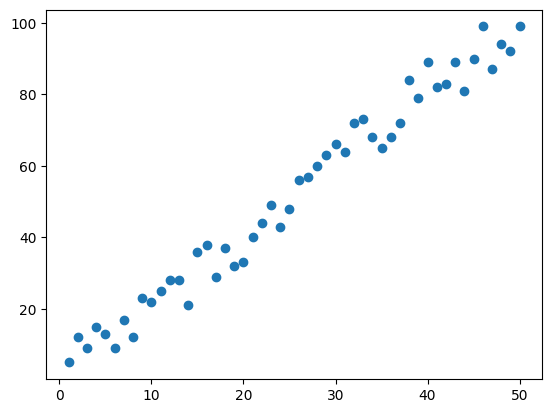

In [89]:
plt.scatter(X.numpy(), y.numpy())

In [90]:
torch.manual_seed(59)

model = nn.Linear(in_features=1, out_features=1)
print(model.weight)
print(model.bias)

Parameter containing:
tensor([[0.1060]], requires_grad=True)
Parameter containing:
tensor([0.9638], requires_grad=True)


In [91]:
class Model(nn.Module):
    def __init__(self, in_features, out_features):
        super().__init__()
        self.linear = nn.Linear(in_features, out_features)
        
    def forward (self,x):
        y_pred = self.linear(x)
        return y_pred
    
    

In [92]:
torch.manual_seed(59)

model = Model(1,1)

In [93]:
for name,param in model.named_parameters():
    print(name, '\t', param.item())

linear.weight 	 0.10597813129425049
linear.bias 	 0.9637961387634277


In [94]:
x = torch.tensor([2.0])
model.forward(x)

tensor([1.1758], grad_fn=<ViewBackward0>)

In [95]:
x1 = np.linspace(0.0,50.0,50)
x1

array([ 0.        ,  1.02040816,  2.04081633,  3.06122449,  4.08163265,
        5.10204082,  6.12244898,  7.14285714,  8.16326531,  9.18367347,
       10.20408163, 11.2244898 , 12.24489796, 13.26530612, 14.28571429,
       15.30612245, 16.32653061, 17.34693878, 18.36734694, 19.3877551 ,
       20.40816327, 21.42857143, 22.44897959, 23.46938776, 24.48979592,
       25.51020408, 26.53061224, 27.55102041, 28.57142857, 29.59183673,
       30.6122449 , 31.63265306, 32.65306122, 33.67346939, 34.69387755,
       35.71428571, 36.73469388, 37.75510204, 38.7755102 , 39.79591837,
       40.81632653, 41.83673469, 42.85714286, 43.87755102, 44.89795918,
       45.91836735, 46.93877551, 47.95918367, 48.97959184, 50.        ])

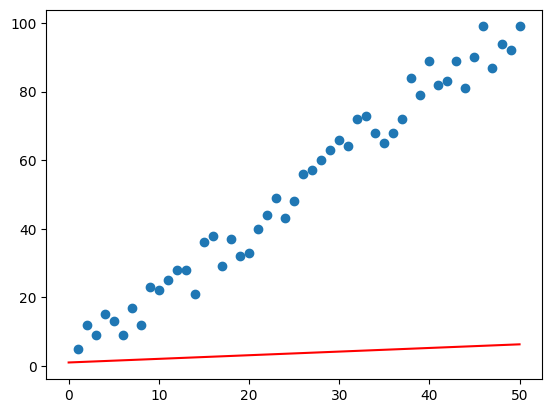

In [96]:
w1 = 0.1059
b1 = 0.9637

y1 = w1*x1 +b1

plt.scatter(X.numpy(), y.numpy())
plt.plot(x1,y1, 'r')

In [97]:
criterion = nn.MSELoss()
optimizer = torch.optim.SGD(model.parameters(), lr=0.001)

In [98]:
epochs = 50
losses = []

for i in range(epochs):
    
    i += 1
    
    y_pred = model.forward(X)
    loss = criterion(y_pred,y)
    
    losses.append(loss.item())
    
    print(f'Epoch {i}, Loss: {loss.item()}, Weight: {model.linear.weight.item()}, Bias: {model.linear.bias.item()}')
    
    optimizer.zero_grad()
    
    loss.backward()
    optimizer.step()

Epoch 1, Loss: 3057.216796875, Weight: 0.10597813129425049, Bias: 0.9637961387634277
Epoch 2, Loss: 1588.53076171875, Weight: 3.334900140762329, Bias: 1.0604636669158936
Epoch 3, Loss: 830.3002319335938, Weight: 1.014832615852356, Bias: 0.9922628402709961
Epoch 4, Loss: 438.8524169921875, Weight: 2.6817996501922607, Bias: 1.0425218343734741
Epoch 5, Loss: 236.7615203857422, Weight: 1.4840211868286133, Bias: 1.0076650381088257
Epoch 6, Loss: 132.42913818359375, Weight: 2.3446059226989746, Bias: 1.0339646339416504
Epoch 7, Loss: 78.56578063964844, Weight: 1.7262252569198608, Bias: 1.0163217782974243
Epoch 8, Loss: 50.75775909423828, Weight: 2.170504093170166, Bias: 1.0302516222000122
Epoch 9, Loss: 36.4012336730957, Weight: 1.8512457609176636, Bias: 1.0214954614639282
Epoch 10, Loss: 28.989229202270508, Weight: 2.0806007385253906, Bias: 1.029038906097412
Epoch 11, Loss: 25.162382125854492, Weight: 1.9157683849334717, Bias: 1.0248701572418213
Epoch 12, Loss: 23.186473846435547, Weight: 2.

Text(0.5, 0, 'Epoch')

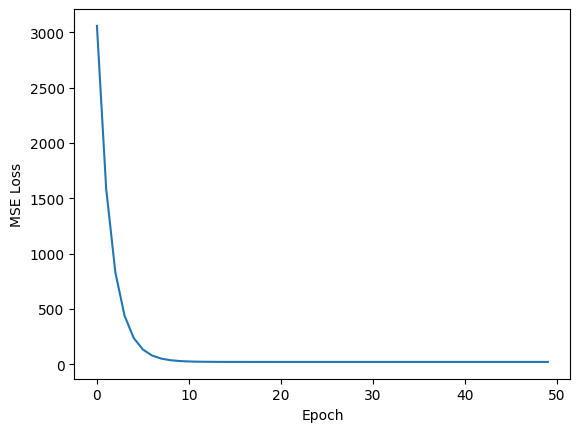

In [99]:
plt.plot(range(epochs), losses)
plt.ylabel('MSE Loss')
plt.xlabel('Epoch')

In [102]:
x = np.linspace(0.0,50.0, 50)
current_weight = model.linear.weight.item()
current_bias = model.linear.bias.item()

predicted_y = current_weight*x + current_bias
predicted_y

array([  1.05575156,   3.08005679,   5.10436203,   7.12866726,
         9.15297249,  11.17727772,  13.20158295,  15.22588818,
        17.25019342,  19.27449865,  21.29880388,  23.32310911,
        25.34741434,  27.37171957,  29.39602481,  31.42033004,
        33.44463527,  35.4689405 ,  37.49324573,  39.51755096,
        41.5418562 ,  43.56616143,  45.59046666,  47.61477189,
        49.63907712,  51.66338236,  53.68768759,  55.71199282,
        57.73629805,  59.76060328,  61.78490851,  63.80921375,
        65.83351898,  67.85782421,  69.88212944,  71.90643467,
        73.9307399 ,  75.95504514,  77.97935037,  80.0036556 ,
        82.02796083,  84.05226606,  86.07657129,  88.10087653,
        90.12518176,  92.14948699,  94.17379222,  96.19809745,
        98.22240268, 100.24670792])

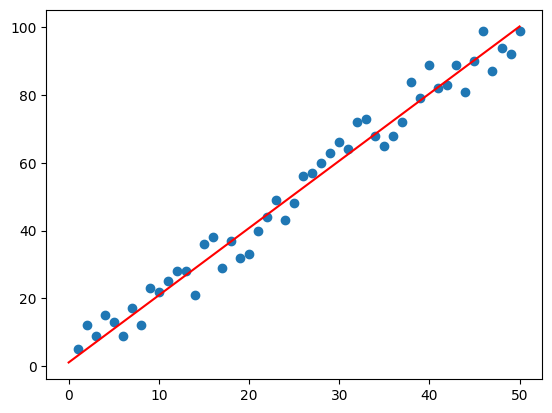

In [103]:
plt.scatter(X.numpy(), y.numpy())
plt.plot(x, predicted_y, 'r')